# Differentially Private Random Forest Classifier - Cancer Risk Dataset

This notebook implements a Differentially Private Random Forest classifier using `diffprivlib` on the Cancer Risk dataset and compares its performance with the standard (non-private) model.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score,
    precision_score,
    recall_score,
)
from diffprivlib.models import RandomForestClassifier as DPRandomForestClassifier
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
import pickle
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train = loaded_data["X_train"]
X_test = loaded_data["X_test"]
y_train = loaded_data["y_train"]
y_test = loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1200, 8)
Test set: (300, 8)


## 3. Load Baseline Results

In [3]:
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: output/baseline_results.csv not found. Please run STD_RF.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.8500
Baseline F1-Score: 0.7594


## 4. Extract Bounds from Pickle File

In [4]:
bounds = loaded_data['bounds']
lower_bound = bounds[0]
upper_bound = bounds[1]

print(f"Bounds extracted from pickle file:")
print(f"Lower bound shape: {lower_bound.shape}")
print(f"Upper bound shape: {upper_bound.shape}")
print(f"Number of features: {len(lower_bound)}")

Bounds extracted from pickle file:
Lower bound shape: (8,)
Upper bound shape: (8,)
Number of features: 8


## 5. Train DP Random Forest at epsilon=1.0 (Detailed Evaluation)

In [5]:
epsilon = 1.0
N_RUNS = 30

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []

print(f"Training DP Random Forest {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42
    dp_rf_model = DPRandomForestClassifier(
        n_estimators=20,
        epsilon=epsilon,
        random_state=seed,
        n_jobs=-1,
        max_depth=4, 
        bounds=bounds
    )

    _t0 = time.perf_counter()
    dp_rf_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    y_dp_pred = dp_rf_model.predict(X_test)

    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_rf_model, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred)
    dp_recall = recall_score(y_test, y_dp_pred)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Random Forest 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.7100 | F1: 0.3741 | Prec: 0.9286 | Rec: 0.2342
  Run  2/30 | Acc: 0.7067 | F1: 0.3433 | Prec: 1.0000 | Rec: 0.2072
  Run  3/30 | Acc: 0.7133 | F1: 0.3857 | Prec: 0.9310 | Rec: 0.2432


  Run  4/30 | Acc: 0.6867 | F1: 0.2769 | Prec: 0.9474 | Rec: 0.1622
  Run  5/30 | Acc: 0.7000 | F1: 0.3382 | Prec: 0.9200 | Rec: 0.2072
  Run  6/30 | Acc: 0.6800 | F1: 0.2500 | Prec: 0.9412 | Rec: 0.1441
  Run  7/30 | Acc: 0.6500 | F1: 0.1026 | Prec: 1.0000 | Rec: 0.0541
  Run  8/30 | Acc: 0.7467 | F1: 0.4933 | Prec: 0.9487 | Rec: 0.3333


  Run  9/30 | Acc: 0.7300 | F1: 0.4255 | Prec: 1.0000 | Rec: 0.2703
  Run 10/30 | Acc: 0.6633 | F1: 0.1653 | Prec: 1.0000 | Rec: 0.0901
  Run 11/30 | Acc: 0.7033 | F1: 0.3308 | Prec: 1.0000 | Rec: 0.1982
  Run 12/30 | Acc: 0.7500 | F1: 0.5098 | Prec: 0.9286 | Rec: 0.3514


  Run 13/30 | Acc: 0.6967 | F1: 0.3158 | Prec: 0.9545 | Rec: 0.1892
  Run 14/30 | Acc: 0.7233 | F1: 0.4113 | Prec: 0.9667 | Rec: 0.2613
  Run 15/30 | Acc: 0.6900 | F1: 0.2901 | Prec: 0.9500 | Rec: 0.1712
  Run 16/30 | Acc: 0.6667 | F1: 0.1935 | Prec: 0.9231 | Rec: 0.1081


  Run 17/30 | Acc: 0.6633 | F1: 0.1653 | Prec: 1.0000 | Rec: 0.0901
  Run 18/30 | Acc: 0.6567 | F1: 0.1760 | Prec: 0.7857 | Rec: 0.0991
  Run 19/30 | Acc: 0.6700 | F1: 0.2326 | Prec: 0.8333 | Rec: 0.1351
  Run 20/30 | Acc: 0.6933 | F1: 0.2923 | Prec: 1.0000 | Rec: 0.1712


  Run 21/30 | Acc: 0.6600 | F1: 0.1500 | Prec: 1.0000 | Rec: 0.0811
  Run 22/30 | Acc: 0.6767 | F1: 0.2362 | Prec: 0.9375 | Rec: 0.1351
  Run 23/30 | Acc: 0.7867 | F1: 0.6098 | Prec: 0.9434 | Rec: 0.4505
  Run 24/30 | Acc: 0.7067 | F1: 0.3623 | Prec: 0.9259 | Rec: 0.2252
  Run 25/30 | Acc: 0.7433 | F1: 0.5032 | Prec: 0.8864 | Rec: 0.3514


  Run 26/30 | Acc: 0.6900 | F1: 0.2901 | Prec: 0.9500 | Rec: 0.1712
  Run 27/30 | Acc: 0.6933 | F1: 0.3030 | Prec: 0.9524 | Rec: 0.1802
  Run 28/30 | Acc: 0.7000 | F1: 0.3382 | Prec: 0.9200 | Rec: 0.2072
  Run 29/30 | Acc: 0.6567 | F1: 0.1488 | Prec: 0.9000 | Rec: 0.0811
  Run 30/30 | Acc: 0.7200 | F1: 0.4000 | Prec: 0.9655 | Rec: 0.2523
Added metrics over the detail runs:
  Balanced Acc:   0.5941 ± 0.0439
  AUROC:          0.8653 ± 0.0219
  Train Time (s): 0.0212 ± 0.0030


## 6. Model Evaluation

In [6]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))
std_precision = float(np.std(detail_precisions))
std_recall = float(np.std(detail_recalls))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} +/- {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} +/- {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f} +/- {std_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f} +/- {std_recall:.4f}")


Results over 30 runs at epsilon=1.0:
  Accuracy:  0.6978 +/- 0.0317
  F1-Score:  0.3138 +/- 0.1201
  Precision: 0.9447 +/- 0.0488
  Recall:    0.1952 +/- 0.0911


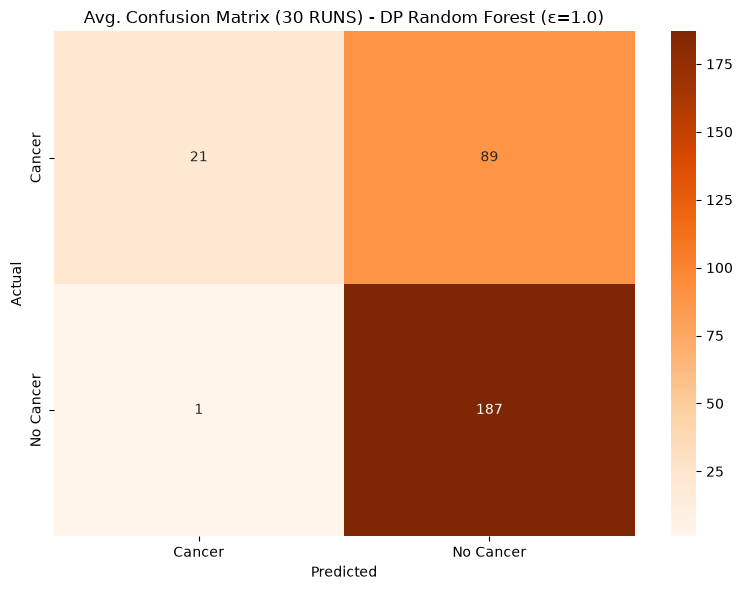

In [7]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN], 
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Cancer', 'No Cancer'],
            yticklabels=['Cancer', 'No Cancer'])
plt.title(f'Avg. Confusion Matrix ({N_RUNS} RUNS) - DP Random Forest (\u03b5={epsilon})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Compare with Baseline

In [8]:
if baseline_accuracy is not None:
    accuracy_loss = baseline_accuracy - avg_accuracy
    f1_loss = baseline_f1 - avg_f1_score
    
    print("=" * 50)
    print("COMPARISON: Standard vs DP Random Forest")
    print("=" * 50)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy (avg): {avg_accuracy:.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"\nStandard Model F1-Score: {baseline_f1:.4f}")
    print(f"DP Model F1-Score (avg): {avg_f1_score:.4f}")
    print(f"F1 Loss:                 {f1_loss:.4f} ({f1_loss*100:.2f}%)")
else:
    print("Baseline results not available. Run STD_RF.ipynb first.")

COMPARISON: Standard vs DP Random Forest

Standard Model Accuracy: 0.8500
DP Model Accuracy (avg): 0.6978
Accuracy Loss:           0.1522 (15.22%)

Standard Model F1-Score: 0.7594
DP Model F1-Score (avg): 0.3138
F1 Loss:                 0.4456 (44.56%)


## 8. Prepare JSON Report Structure

In [9]:
import json
import os

os.makedirs('output', exist_ok=True)

N_RUNS = 30

parameters = {
    "n_estimators": 20,
    "random_state": "varies (30 seeds per epsilon)",
    "n_jobs": -1,
    "max_depth": 4,
    "n_runs": N_RUNS,
}

results_json = {
    "model_type": "Differentially Private Random Forest",
    "dataset": "Cancer Risk Prediction",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

## 9. Epsilon vs Accuracy Analysis

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy.

In [10]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]

results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}

print(f"Training DP Random Forest with {N_RUNS} runs per epsilon value...")
print("=" * 80)

for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []

    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42

        dp_model = DPRandomForestClassifier(
            n_estimators=20,
            epsilon=eps,
            random_state=seed,
            n_jobs=-1,
            max_depth=4,
            bounds=bounds
        )
        _t0 = time.perf_counter()
        dp_model.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        y_pred = dp_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_model, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_model, f'output/model/dp_rf_model_eps_{eps}.pkl')

    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)

    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)

    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps),
        "n_runs": N_RUNS,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "precision_mean": prec_mean,
        "precision_std": prec_std,
        "recall_mean": rec_mean,
        "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy()
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())

    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")

print("=" * 80)
print("Training complete!")

Training DP Random Forest with 30 runs per epsilon value...


Model successfully exported to output/model/dp_rf_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.6736±0.0255 | F1: 0.3147±0.1280 | Prec: 0.7149±0.1183 | Rec: 0.2183±0.1151
Model successfully exported to output/model/dp_rf_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.6861±0.0265 | F1: 0.2967±0.1268 | Prec: 0.8710±0.1039 | Rec: 0.1910±0.1016
Model successfully exported to output/model/dp_rf_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.6907±0.0284 | F1: 0.2979±0.1221 | Prec: 0.9009±0.0794 | Rec: 0.1859±0.0872
Model successfully exported to output/model/dp_rf_model_eps_0.6.pkl


...

ε=  2.0 | Acc: 0.6990±0.0304 | F1: 0.3222±0.1186 | Prec: 0.9356±0.0590 | Rec: 0.2015±0.0874
Model successfully exported to output/model/dp_rf_model_eps_4.0.pkl


ε=  4.0 | Acc: 0.7004±0.0326 | F1: 0.3244±0.1261 | Prec: 0.9461±0.0520 | Rec: 0.2039±0.0952
Model successfully exported to output/model/dp_rf_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.7008±0.0305 | F1: 0.3257±0.1203 | Prec: 0.9499±0.0470 | Rec: 0.2039±0.0894
Model successfully exported to output/model/dp_rf_model_eps_8.0.pkl


ε=  8.0 | Acc: 0.7010±0.0308 | F1: 0.3267±0.1213 | Prec: 0.9491±0.0479 | Rec: 0.2048±0.0902
Model successfully exported to output/model/dp_rf_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.7009±0.0307 | F1: 0.3261±0.1207 | Prec: 0.9498±0.0476 | Rec: 0.2042±0.0897
Training complete!


## 10. Save JSON Report

In [11]:
with open('output/dp_rf_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'output/dp_rf_report.json'")
print(f"Total epsilon values: {len(results_json['epsilon_results'])}")

Results saved to 'output/dp_rf_report.json'
Total epsilon values: 15


In [12]:
results_df = pd.DataFrame(results)

if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100

print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.673556      0.025458       0.314653      0.128049        0.714937       0.118337     0.218318    0.115129                0.579618               0.040139      0.736187     0.050461         0.022106        0.003737            0.176444          17.644444
     0.2       0.686111      0.026487       0.296706      0.126754        0.871004       0.103869     0.190991    0.101617                0.583943               0.041067      0.801684     0.037114         0.022140        0.009304            0.163889          16.388889
     0.4       0.690667      0.028394       0.297872      0.122091        0.900895       0.079426     0.185886    0.087206                0.586506       

## 11. Visualization: Privacy Budget vs Accuracy

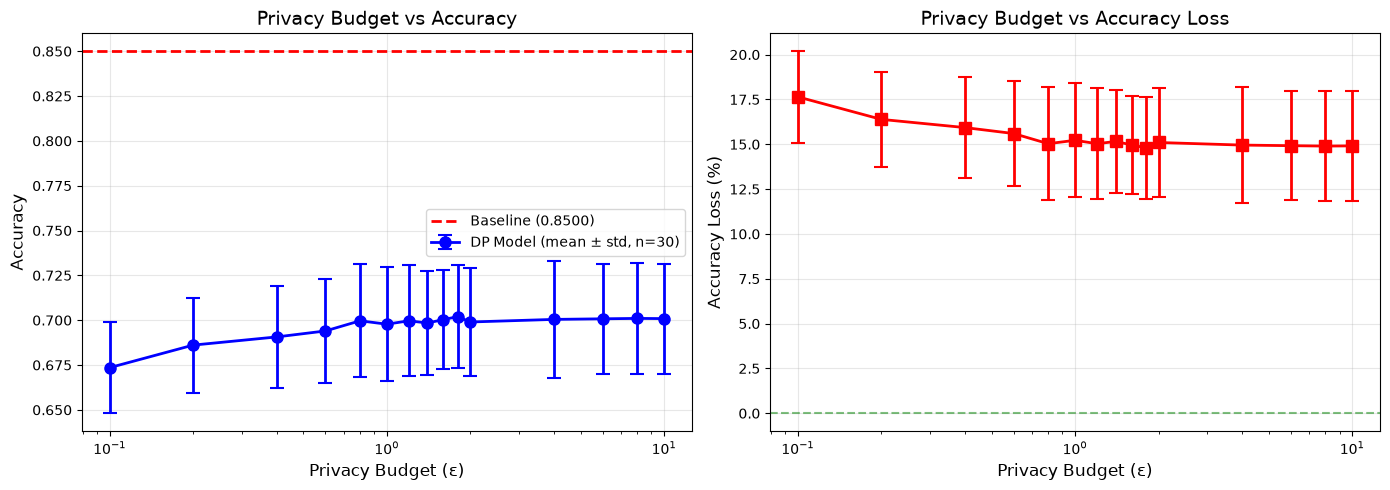


Plot saved as 'output/privacy_accuracy_tradeoff.png'


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.errorbar(
    results_df['epsilon'],
    results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'],
    fmt='bo-', linewidth=2, markersize=8,
    capsize=5, capthick=1.5,
    label=f'DP Model (mean \u00b1 std, n={N_RUNS})'
)
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--',
                linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(
        results_df['epsilon'],
        results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100,
        fmt='rs-', linewidth=2, markersize=8,
        capsize=5, capthick=1.5
    )
    ax2.set_xlabel('Privacy Budget (\u03b5)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('output/privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'output/privacy_accuracy_tradeoff.png'")

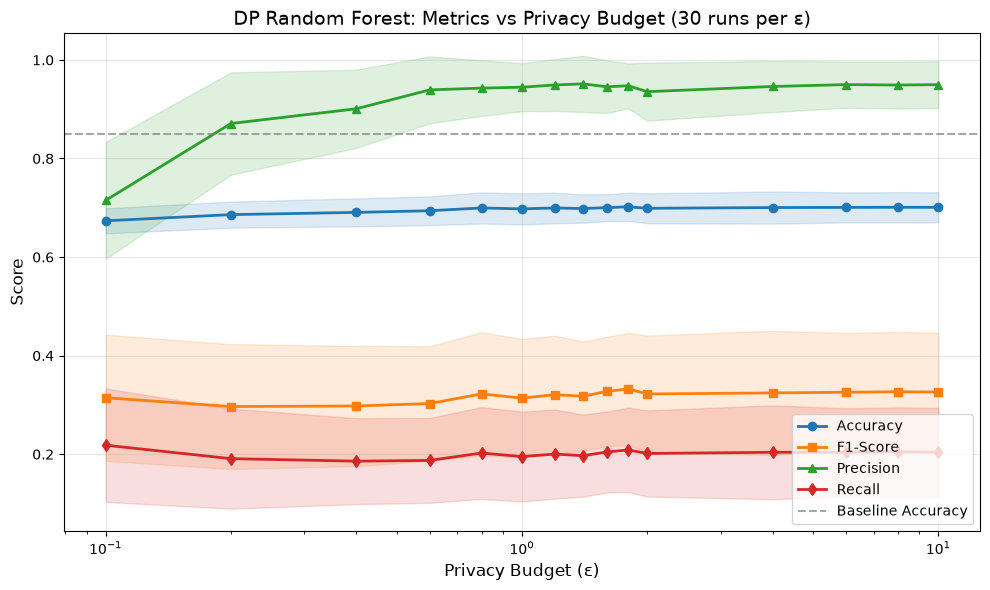

Plot saved as 'output/all_metrics_vs_epsilon.png'


In [14]:
plt.figure(figsize=(10, 6))

metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]

for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values

    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()

    plt.fill_between(
        eps_vals,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.15,
        color=color
    )

if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
                alpha=0.7, label='Baseline Accuracy')

plt.xlabel('Privacy Budget (\u03b5)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP Random Forest: Metrics vs Privacy Budget ({N_RUNS} runs per \u03b5)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('output/all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'output/all_metrics_vs_epsilon.png'")

## 12. Save Results

In [15]:
results_df.to_csv('output/dp_results.csv', index=False)
print("DP results saved to 'output/dp_results.csv'")

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard RF) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Random Forest Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

DP results saved to 'output/dp_results.csv'

FINAL SUMMARY

Baseline (Standard RF) Accuracy: 0.8500

DP Random Forest Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.673556      0.025458       0.314653      0.128049        0.714937       0.118337     0.218318    0.115129                0.579618               0.040139      0.736187     0.050461         0.022106        0.003737            0.176444          17.644444
     0.2       0.686111      0.026487       0.296706      0.126754        0.871004       0.103869     0.190991    0.101617                0.583943               0.041067      0.801684     0.037114         0.022140        0.009304            0.163889          16.388889
     0.4       0.690667      0.028394       